In [2]:
# Install dependencies if necessary.
%pip install pandas numpy matplotlib seaborn scipy openpyxl

   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   --------------- ------------------------ 13.9/36.6 MB 87.4 MB/s eta 0:00:01
   ------------------------------------- -- 34.1/36.6 MB 94.2 MB/s eta 0:00:01
   ---------------------------------------  36.4/36.6 MB 92.5 MB/s eta 0:00:01
   ---------------------------------------- 36.6/36.6 MB 64.7 MB/s  0:00:00

   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]


In [19]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_excel("C:/Users/ryadl/Desktop/EMFIT_local/Emfit/documentation/MS_Metadata.xlsx", 
                   sheet_name=3)

print(df.head(30))
print(df.columns.tolist())

   subject  Subject Group   EASI  Male   Age Age (MRI)  Onset before 2  \
0      MS1  sub-001     2     17   1.0  16.0       NaN             0.0   
1      MS2  sub-002     2    7.8   1.0  18.0       NaN             0.0   
2      MS3  sub-003     2    3.6   0.0  15.0       NaN             1.0   
3    MS4V1  sub-004     1   13.6   0.0  16.0       NaN             1.0   
4    MS4V2      NaN     1   12.8   0.0   NaN       NaN             NaN   
5      MS5  sub-005     2  17.25   1.0  12.0       NaN             1.0   
6      MS6  sub-006     2    0.8   1.0  17.0       NaN             1.0   
7      MS7  sub-007     2   16.6   0.0  13.0       NaN             1.0   
8      MS8  sub-008     2    2.2   0.0  16.0       NaN             1.0   
9      MS9  sub-009     2    2.4   1.0  16.0       NaN             0.0   
10    MS10  sub-010     3      0   0.0  16.0       NaN             NaN   
11    MS12  sub-012     3      0   1.0  15.0       NaN             NaN   
12    MS14  sub-014     2      3   0.0

In [20]:
# Drop unnamed columns
df = df.drop(columns=[col for col in df.columns if col.startswith('Unnamed')])

# Drop Subject column - redundant with subject
df = df.drop(columns=['Subject'])

# Drops any subject rows with NA.
df = df[df['subject'].notna()]

# Forward fill V2 style rows - inherit demographics from V1
df['Age'] = df['Age'].ffill()
df['Male'] = df['Male'].ffill()
df['Onset before 2'] = df['Onset before 2'].ffill()

# Create binary eczema vs control group
df['group_binary'] = df['Group'].apply(lambda x: 'eczema' if x in [1, 2] else 'control')

# Drop V2 rows to avoid duplicate participants in demographic analysis
df = df[~df['subject'].str.contains('V2', na=False)]

print(df['group_binary'].value_counts())
print(df.shape)

group_binary
eczema     49
control    27
Name: count, dtype: int64
(76, 8)


In [ ]:
from scipy.stats import mannwhitneyu, fisher_exact

eczema = df[df['group_binary'] == 'eczema']
control = df[df['group_binary'] == 'control']

# Mann-Whitney U for continuous variable
age_stat, age_p = mannwhitneyu(eczema['Age'].dropna(), control['Age'].dropna(), alternative='two-sided')

# Fisher's exact for categorical variables
gender_table = pd.crosstab(df['group_binary'], df['Male'])
gender_OR, gender_p = fisher_exact(gender_table)

# Onset before 2 only within eczema group
onset_table = pd.crosstab(eczema['Group'], eczema['Onset before 2'].dropna())
onset_OR, onset_p = fisher_exact(onset_table)

print("=== Statistical Comparisons: Eczema vs Control ===")
print(f"Age:            U={age_stat:.1f}, p={age_p:.4f}")
print(f"Gender (Male):  OR={gender_OR:.2f}, p={gender_p:.4f}")
print(f"\n=== Onset before 2 (Eczema only: Severe vs Moderate) ===")
print(f"Onset <2yrs:    OR={onset_OR:.2f}, p={onset_p:.4f}")

print(pd.crosstab(eczema['Group'], eczema['Onset before 2'].dropna())) # Proves that onset before 2 doesn't distinguish severe from moderate eczema.


=== Statistical Comparisons: Eczema vs Control ===
Age:            U=479.5, p=0.0452
Gender (Male):  OR=0.88, p=0.8141

=== Onset before 2 (Eczema only: Severe vs Moderate) ===
Onset <2yrs:    OR=0.78, p=1.0000
Onset before 2  0.0  1.0
Group                   
1                 3   10
2                10   26


In [24]:
# Summary statistics table
summary = df.groupby('group_binary').agg(
    n=('subject', 'count'),
    age_median=('Age', 'median'),
    age_mean=('Age', 'mean'),
    age_std=('Age', 'std'),
    male_n=('Male', 'sum'),
    easi_median=('EASI', 'median'),
    easi_mean=('EASI', 'mean'),
    easi_std=('EASI', 'std')
).round(2)

print(summary)

               n  age_median  age_mean  age_std  male_n easi_median  \
group_binary                                                          
control       27        15.0     15.19     1.59    13.0         0.0   
eczema        49        15.0     14.35     1.69    22.0         7.8   

              easi_mean  easi_std  
group_binary                       
control             0.0      0.00  
eczema        10.542553      8.46  


C:\Users\ryadl\AppData\Local\Temp\ipykernel_11456\473357195.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='group_binary', y='Age', palette={'eczema': '#E87E7E', 'control': '#7EB6E8'}, ax=ax)


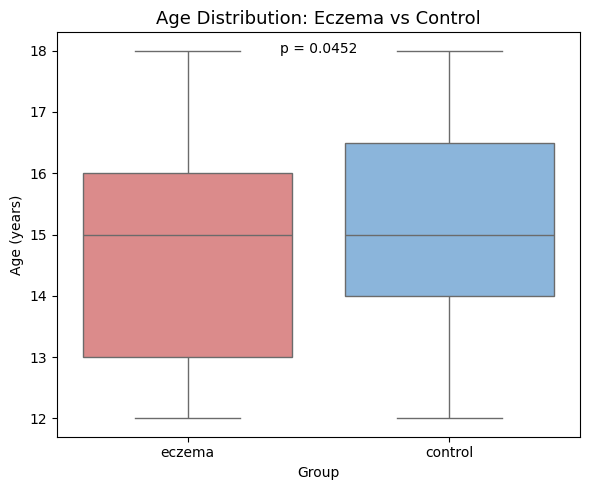

In [ ]:
# Box plot comparing age distribution between eczema and control.
fig, ax = plt.subplots(figsize=(6, 5))

sns.boxplot(data=df, x='group_binary', y='Age', palette={'eczema': '#E87E7E', 'control': '#7EB6E8'}, ax=ax)

ax.set_title('Age Distribution: Eczema vs Control', fontsize=13)
ax.set_xlabel('Group')
ax.set_ylabel('Age (years)')
ax.annotate(f'p = {age_p:.4f}', xy=(0.5, 0.95), xycoords='axes fraction', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

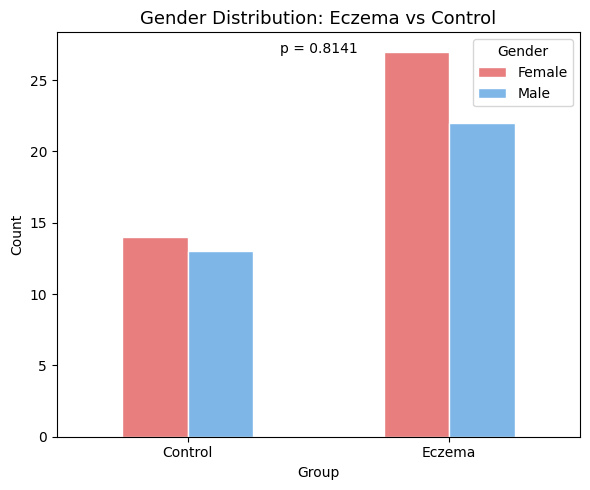

In [ ]:
# Bar plot compared number of males and females in each group.
fig, ax = plt.subplots(figsize=(6, 5))

gender_counts = df.groupby(['group_binary', 'Male']).size().unstack()
gender_counts.columns = ['Female', 'Male']
gender_counts.plot(kind='bar', color=['#E87E7E', '#7EB6E8'], ax=ax, edgecolor='white')

ax.set_title('Gender Distribution: Eczema vs Control', fontsize=13)
ax.set_xlabel('Group')
ax.set_ylabel('Count')
ax.set_xticklabels(['Control', 'Eczema'], rotation=0)
ax.legend(title='Gender')
ax.annotate(f'p = {gender_p:.4f}', xy=(0.5, 0.95), xycoords='axes fraction', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

C:\Users\ryadl\AppData\Local\Temp\ipykernel_11456\1142428613.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Severe (1)', 'Moderate (2)'])


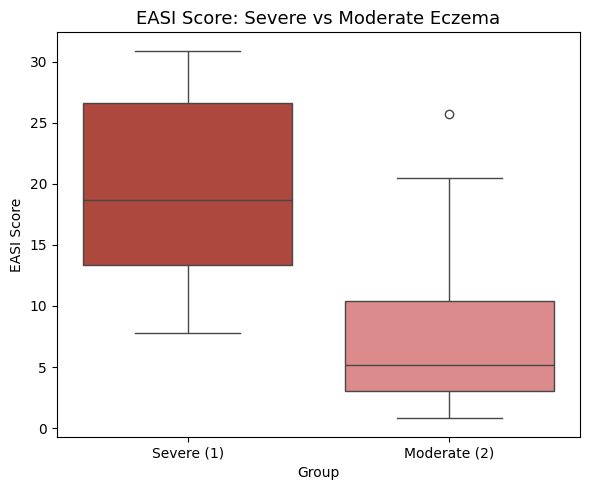

In [31]:
fig, ax = plt.subplots(figsize=(6, 5))

sns.boxplot(data=eczema, x='Group', y='EASI', hue='Group', palette=['#C0392B', '#E87E7E'], 
            legend=False, ax=ax)

ax.set_title('EASI Score: Severe vs Moderate Eczema', fontsize=13)
ax.set_xlabel('Group')
ax.set_ylabel('EASI Score')
ax.set_xticklabels(['Severe (1)', 'Moderate (2)'])

plt.tight_layout()
plt.show()